# 02. Edge Detection (Gambar Pribadi)


<table>
  <tr>
    <td>Nama</td>
    <td>Steven Tjhia</td>
  </tr>
  <tr>
    <td>NIM</td>
    <td>13522103</td>
  </tr>
  <tr>
    <td>Fitur Unik</td>
    <td>
      1. Dilakukan konversi dari RGBA menjadi Grayscale
    </td>
  </tr>
</table>

## 2.1 Inisiasi

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, io, img_as_float, img_as_ubyte, feature
from skimage import filters
from skimage.color import rgb2gray, rgba2rgb

In [2]:
output_dir = 'pribadi_output'

## 2.2 Utility Functions

In [3]:
def display_comparison(raw, filtered, filter_name, params_str, img_name):
    """Displays the raw and edge-detected images side-by-side."""
    fig, axes = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)
    ax = axes.ravel()

    ax[0].imshow(raw, cmap=plt.cm.gray, vmin=0, vmax=1)
    ax[0].set_title(f'Raw ({img_name})')
    ax[0].axis('off')

    # Display edges (typically black and white or grayscale magnitude)
    ax[1].imshow(filtered, cmap=plt.cm.gray) # Use gray cmap for edges
    ax[1].set_title(f'{filter_name} Edges\n{params_str}')
    ax[1].axis('off')

    plt.tight_layout()
    plt.show()

## 2.3 Experiments

### 2.3.1 Load Images

In [4]:
input_dir = 'pribadi_input'
input_filename = 'pribadi.png'
image_path = os.path.join(input_dir, input_filename)
image_name = 'pribadi'

print("--- Loading Image ---")
images = {}
try:
    # Check if the directory and file exist
    if not os.path.isdir(input_dir):
        print(f"Error: Input directory '{input_dir}' not found.")
    elif not os.path.isfile(image_path):
        print(f"Error: Input file '{image_path}' not found.")
    else:
        # Load the specified image
        img = img_as_float(io.imread(image_path))
        images[image_name] = img # Store it in the dictionary
        print(f"Image '{image_path}' loaded successfully.")

except Exception as e:
    print(f"Error loading image '{image_path}': {e}")

--- Loading Image ---
Image 'pribadi_input\pribadi.png' loaded successfully.


### 2.3.2 Sobel

#### 2.3.2.1 RGBA


--- Applying Sobel Filter ---
Parameters: Standard Sobel (3x3 kernels)

Processing pribadi...
Saved Sobel edges to: pribadi_output\sobel_output_pribadi.png


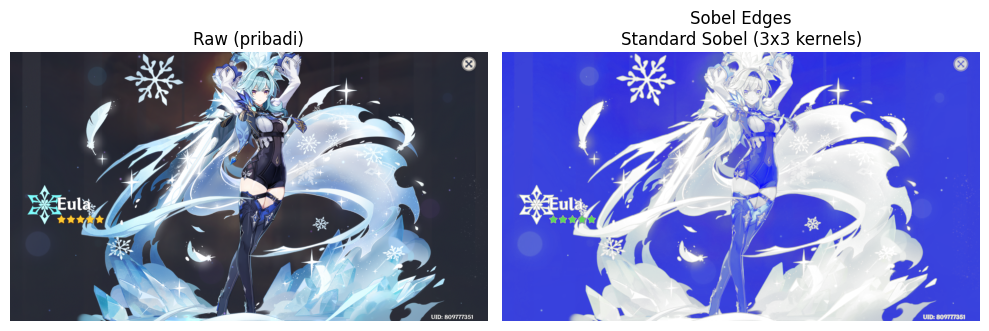

In [5]:
sobel_params_str = 'Standard Sobel (3x3 kernels)' # Parameter string
print("\n--- Applying Sobel Filter ---")
print(f"Parameters: {sobel_params_str}")
for name, img in images.items():
    print(f"\nProcessing {name}...")

    edge_sobel = filters.sobel(img)
    max_val = edge_sobel.max()
    if max_val > 0:
        edge_sobel_float = edge_sobel / max_val # Normalized float for display
    else:
        edge_sobel_float = edge_sobel
    edge_sobel_ubyte = img_as_ubyte(edge_sobel_float) # Ubyte for saving

    output_filename = os.path.join(output_dir, f'sobel_output_{name}.png')
    try:
        io.imsave(output_filename, edge_sobel_ubyte)
        print(f"Saved Sobel edges to: {output_filename}")
    except Exception as e:
        print(f"Error saving image {output_filename}: {e}")
    display_comparison(img, edge_sobel_float, 'Sobel', sobel_params_str, name)

#### 2.3.2.2 Grayscale


--- Applying Sobel Filter ---
Parameters: Standard Sobel (3x3 kernels)

Processing pribadi...
Saved Sobel edges to: pribadi_output\sobel_output_pribadi.png


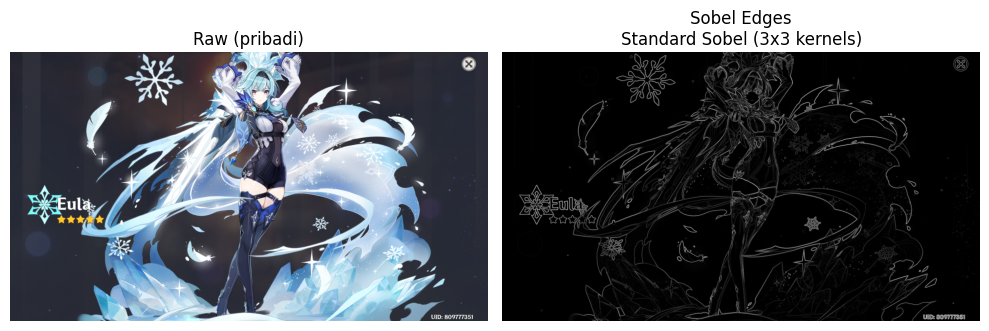

In [8]:
sobel_params_str = 'Standard Sobel (3x3 kernels)' # Parameter string
print("\n--- Applying Sobel Filter ---")
print(f"Parameters: {sobel_params_str}")
for name, img in images.items():
    print(f"\nProcessing {name}...")
    img_rgb = rgba2rgb(img)
    img_gray = rgb2gray(img_rgb)
    edge_sobel = filters.sobel(img_gray)
    max_val = edge_sobel.max()
    if max_val > 0:
        edge_sobel_float = edge_sobel / max_val # Normalized float for display
    else:
        edge_sobel_float = edge_sobel
    edge_sobel_ubyte = img_as_ubyte(edge_sobel_float) # Ubyte for saving

    output_filename = os.path.join(output_dir, f'sobel_output_{name}.png')
    try:
        io.imsave(output_filename, edge_sobel_ubyte)
        print(f"Saved Sobel edges to: {output_filename}")
    except Exception as e:
        print(f"Error saving image {output_filename}: {e}")
    display_comparison(img, edge_sobel_float, 'Sobel', sobel_params_str, name)

### 2.3.3 Canny

Params

<table>
    <tr>
        <td>Sigma (stdev)</td>
        <td>1.3</td>
    </tr>
</table>


--- Applying Canny Filter ---
Parameters: sigma=1.3, low=0.10, high=0.25

Processing pribadi...
Saved Canny edges to: pribadi_output\canny_output_pribadi.png


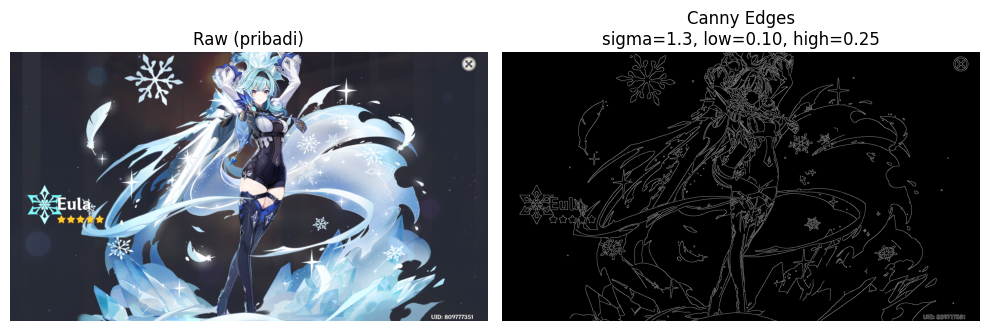


--- Edge detection complete. ---
Results saved in 'pribadi_output' directory.


In [6]:
canny_sigma = 1.3
canny_low = 0.1
canny_high = 0.25
# Parameter string
canny_params_str = f'sigma={canny_sigma}, low={canny_low:.2f}, high={canny_high:.2f}'

print("\n--- Applying Canny Filter ---")
print(f"Parameters: {canny_params_str}")
for name, img in images.items():
    print(f"\nProcessing {name}...")

    if img.ndim == 3:
        image_gray = img.mean(axis=2)
    else:
        image_gray = img

    edges_canny = feature.canny(image_gray,
                                sigma=canny_sigma,
                                low_threshold=canny_low,
                                high_threshold=canny_high)
    edge_canny_float = edges_canny.astype(float) # Float 0/1 for display
    edge_canny_ubyte = img_as_ubyte(edges_canny) # Ubyte 0/255 for saving

    output_filename = os.path.join(output_dir, f'canny_output_{name}.png')
    try:
        io.imsave(output_filename, edge_canny_ubyte)
        print(f"Saved Canny edges to: {output_filename}")
    except Exception as e:
        print(f"Error saving image {output_filename}: {e}")
    display_comparison(img, edge_canny_float, 'Canny', canny_params_str, name)

# --- Conclusion ---
print("\n--- Edge detection complete. ---")
print(f"Results saved in '{output_dir}' directory.")

Params

<table>
    <tr>
        <td>Sigma (stdev)</td>
        <td>5.0</td>
    </tr>
</table>


--- Applying Canny Filter ---
Parameters: sigma=5, low=0.10, high=0.25

Processing pribadi...
Saved Canny edges to: pribadi_output\canny_output_pribadi_sigma_5.png


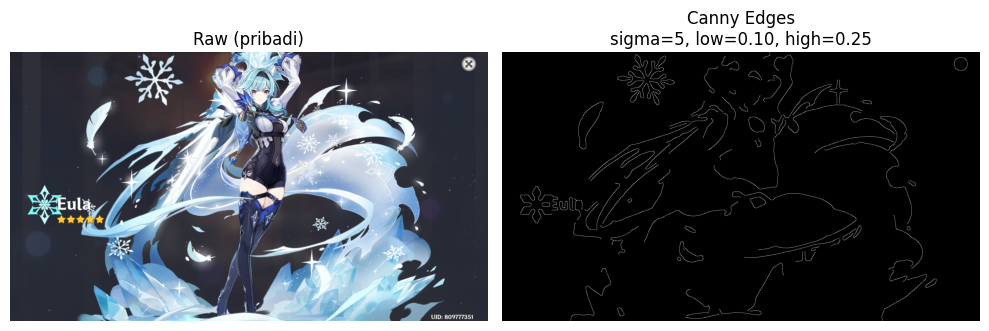


--- Edge detection complete. ---
Results saved in 'pribadi_output' directory.


In [ ]:
canny_sigma = 5.0
canny_low = 0.1
canny_high = 0.25
# Parameter string
canny_params_str = f'sigma={canny_sigma}, low={canny_low:.2f}, high={canny_high:.2f}'

print("\n--- Applying Canny Filter ---")
print(f"Parameters: {canny_params_str}")
for name, img in images.items():
    print(f"\nProcessing {name}...")

    if img.ndim == 3:
        image_gray = img.mean(axis=2)
    else:
        image_gray = img

    edges_canny = feature.canny(image_gray,
                                sigma=canny_sigma,
                                low_threshold=canny_low,
                                high_threshold=canny_high)
    edge_canny_float = edges_canny.astype(float) # Float 0/1 for display
    edge_canny_ubyte = img_as_ubyte(edges_canny) # Ubyte 0/255 for saving

    output_filename = os.path.join(output_dir, f'canny_output_{name}_sigma_5.png')
    try:
        io.imsave(output_filename, edge_canny_ubyte)
        print(f"Saved Canny edges to: {output_filename}")
    except Exception as e:
        print(f"Error saving image {output_filename}: {e}")
    display_comparison(img, edge_canny_float, 'Canny', canny_params_str, name)

# --- Conclusion ---
print("\n--- Edge detection complete. ---")
print(f"Results saved in '{output_dir}' directory.")